# PJM HOURLY ENERGY CONSUMPTION

https://www.kaggle.com/datasets/robikscube/hourly-energy-consumption/data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


energy_data = pd.read_csv('AEP_hourly.csv')
energy_data = energy_data.rename(columns={'Datetime': 'date', 'AEP_MW': 'mw'})
energy_data['date'] = pd.to_datetime(energy_data['date'])
energy_data = energy_data.sort_values('date')

print(energy_data.head())

                    date       mw
2183 2004-10-01 01:00:00  12379.0
2184 2004-10-01 02:00:00  11935.0
2185 2004-10-01 03:00:00  11692.0
2186 2004-10-01 04:00:00  11597.0
2187 2004-10-01 05:00:00  11681.0


## VISUALIZATION
Let's plot some graphs and see what we are working with

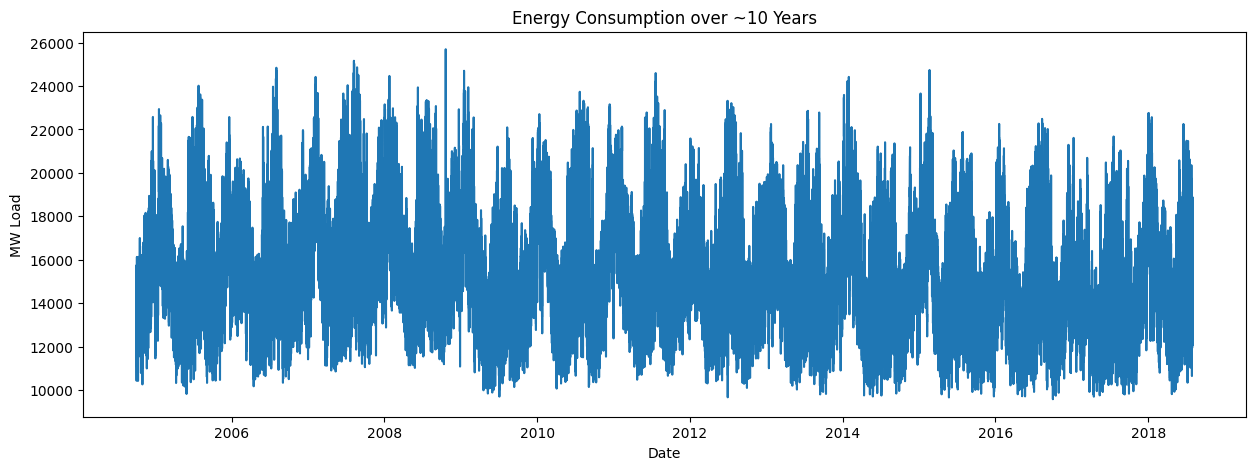

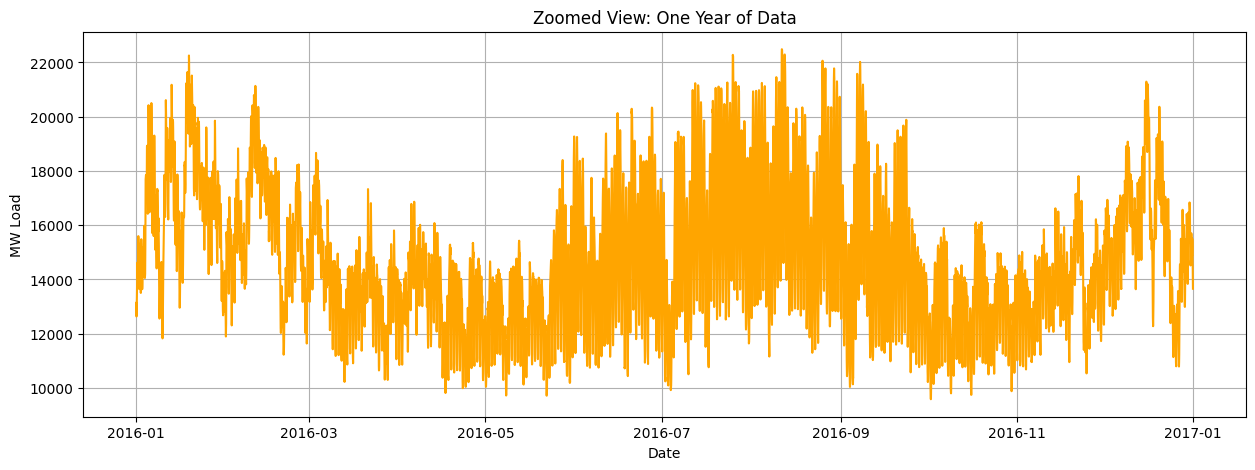

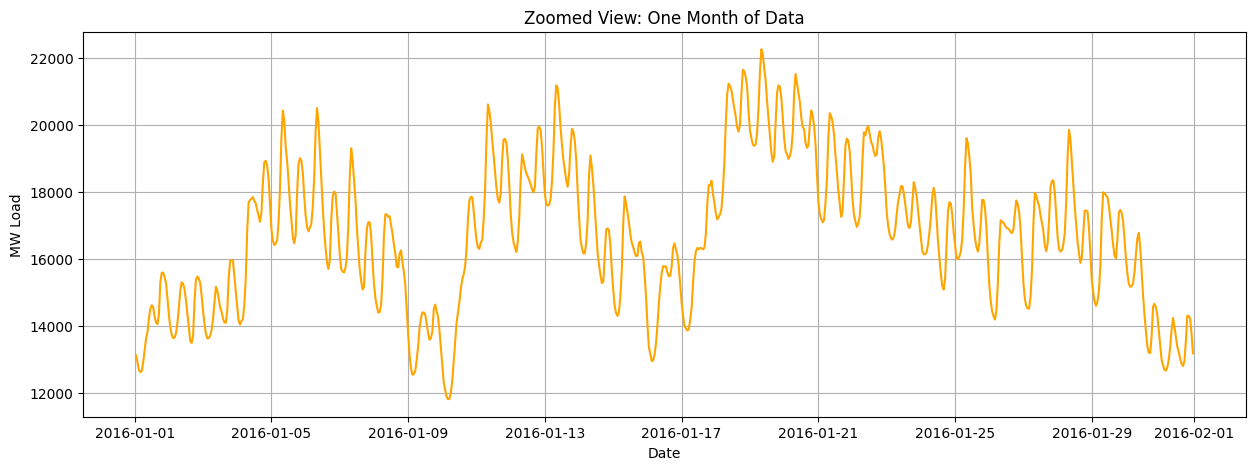

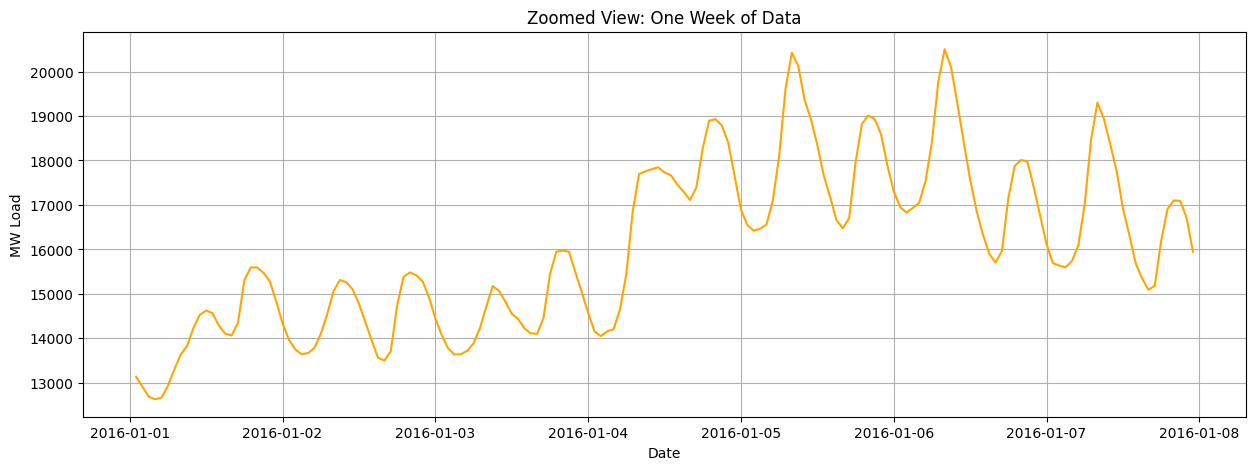

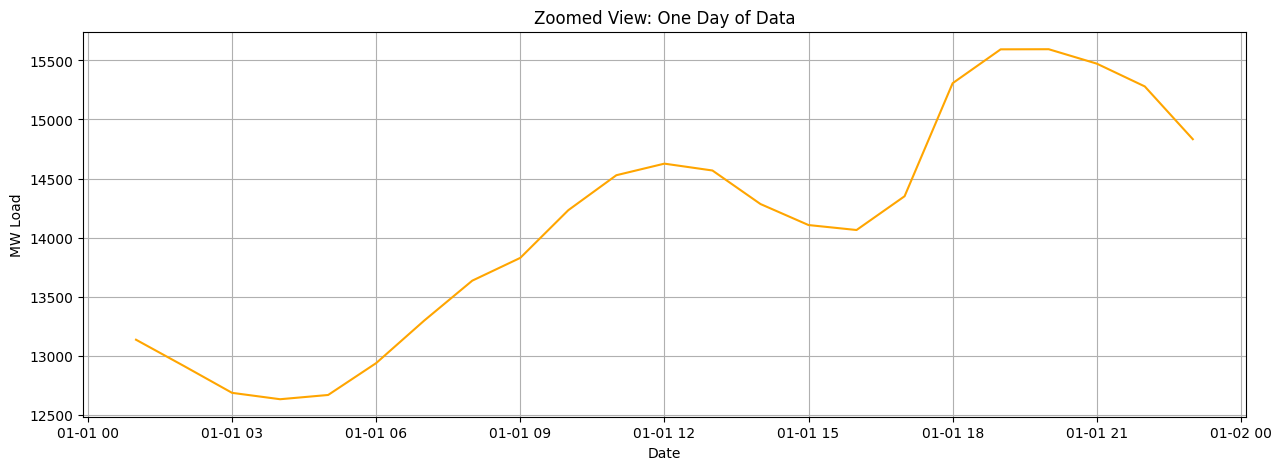

In [2]:
df = energy_data.copy()

# plot the entire dataset
plt.figure(figsize=(15, 5))
plt.plot(df['date'], df['mw'])
plt.title("Energy Consumption over ~10 Years")
plt.xlabel("Date")
plt.ylabel("MW Load")
plt.show()


# plot one year
subset = df[(df['date'] > '2016-01-01') & (df['date'] < '2017-01-01')]

plt.figure(figsize=(15, 5))
plt.plot(subset['date'], subset['mw'], color='orange')
plt.title("Zoomed View: One Year of Data")
plt.xlabel("Date")
plt.ylabel("MW Load")
plt.grid(True)
plt.show()

# plot one month
subset = df[(df['date'] > '2016-01-01') & (df['date'] < '2016-02-01')]

plt.figure(figsize=(15, 5))
plt.plot(subset['date'], subset['mw'], color='orange')
plt.title("Zoomed View: One Month of Data")
plt.xlabel("Date")
plt.ylabel("MW Load")
plt.grid(True)
plt.show()

# plot one week
subset = df[(df['date'] > '2016-01-01') & (df['date'] < '2016-01-08')]

plt.figure(figsize=(15, 5))
plt.plot(subset['date'], subset['mw'], color='orange')
plt.title("Zoomed View: One Week of Data")
plt.xlabel("Date")
plt.ylabel("MW Load")
plt.grid(True)
plt.show()


# plot one day
subset = df[(df['date'] > '2016-01-01') & (df['date'] < '2016-01-02')]

plt.figure(figsize=(15, 5))
plt.plot(subset['date'], subset['mw'], color='orange')
plt.title("Zoomed View: One Day of Data")
plt.xlabel("Date")
plt.ylabel("MW Load")
plt.grid(True)
plt.show()

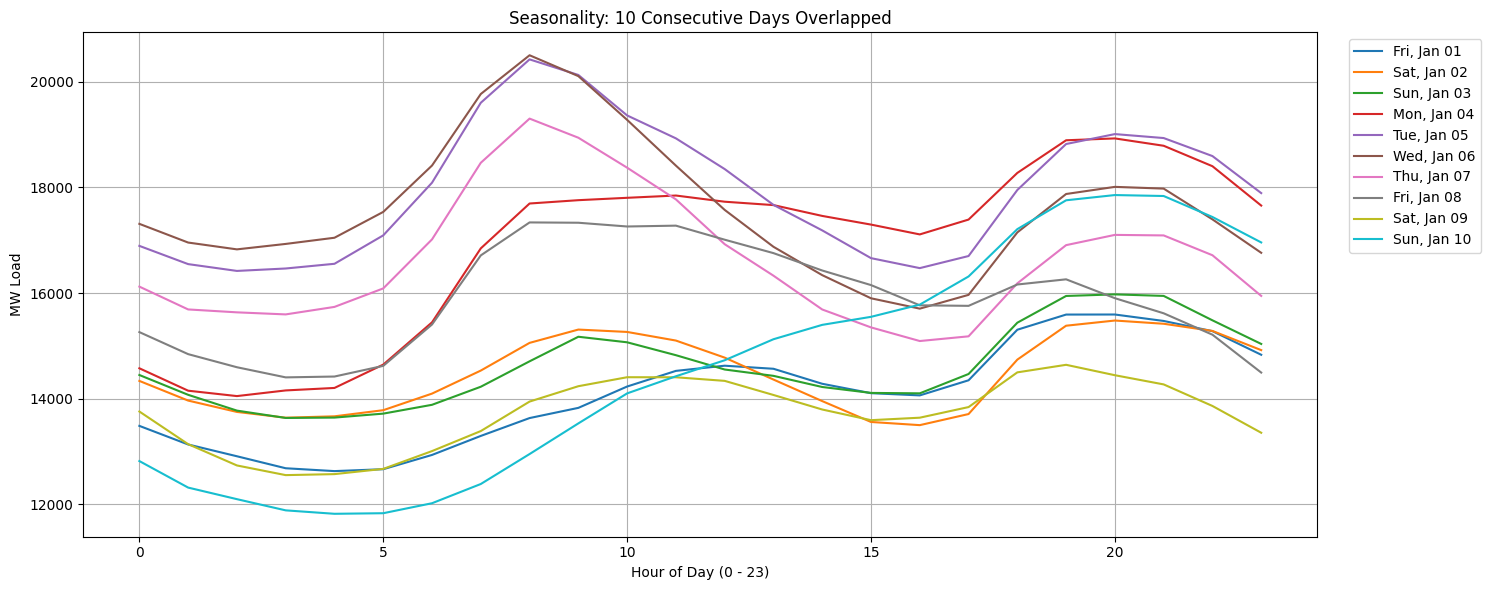

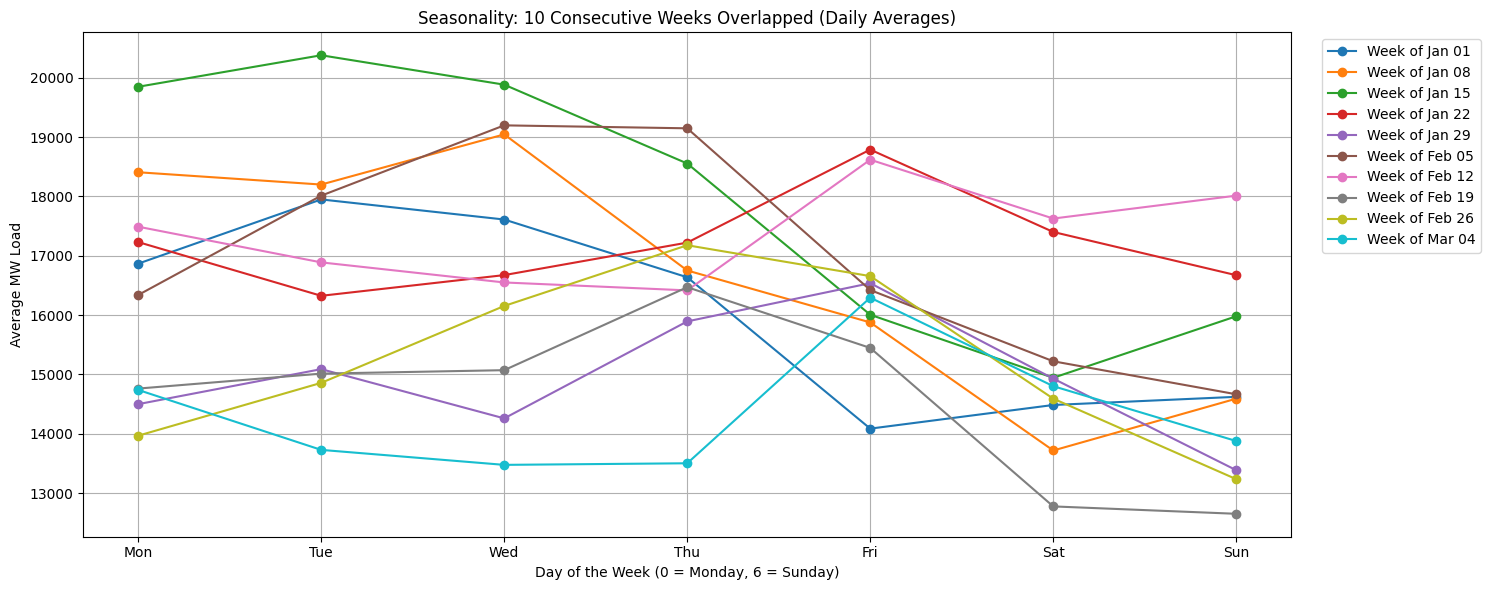

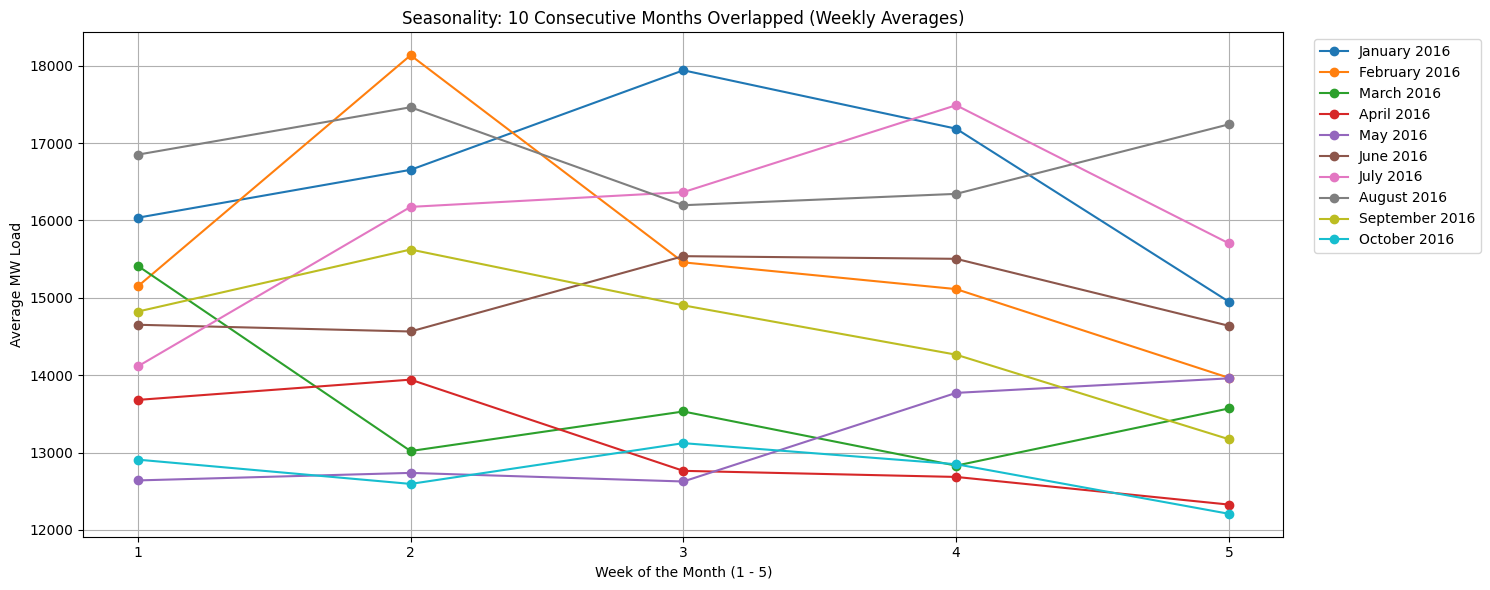

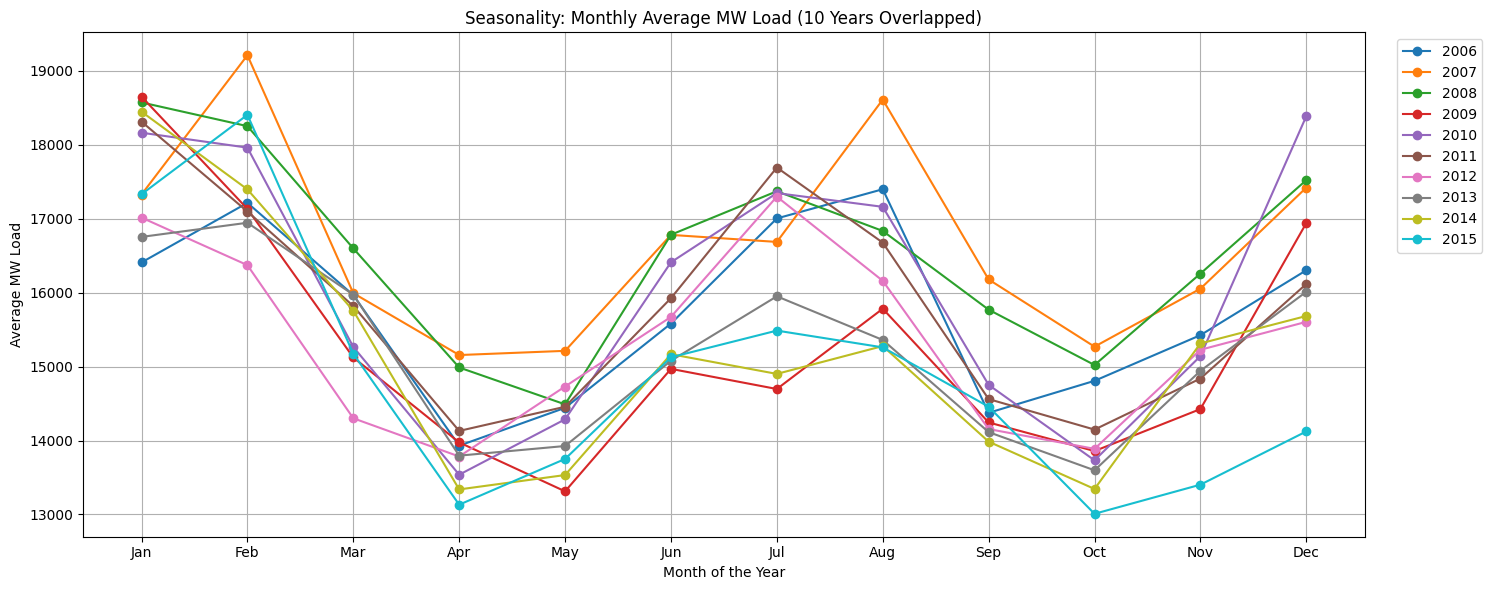

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the date column is in datetime format (if not already)
df['date'] = pd.to_datetime(df['date'])

# Pick a starting point for your overlaps (change this to whatever date you prefer)
start_date = pd.to_datetime('2016-01-01')

# -------------------------------------------------------------------
# Plot 1: 10 Consecutive Days Overlapped
# -------------------------------------------------------------------
plt.figure(figsize=(15, 6))
for i in range(10):
    day_start = start_date + pd.Timedelta(days=i)
    day_end = day_start + pd.Timedelta(days=1)
    
    subset = df[(df['date'] >= day_start) & (df['date'] < day_end)].copy()
    if not subset.empty:
        subset['hour_of_day'] = subset['date'].dt.hour + (subset['date'].dt.minute / 60.0)
        plt.plot(subset['hour_of_day'], subset['mw'], label=day_start.strftime('%a, %b %d'))

plt.title("Seasonality: 10 Consecutive Days Overlapped")
plt.xlabel("Hour of Day (0 - 23)")
plt.ylabel("MW Load")
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot 2: 10 Consecutive Weeks Overlapped (Daily Averages)
# -------------------------------------------------------------------
plt.figure(figsize=(15, 6))
for i in range(10):
    week_start = start_date + pd.Timedelta(weeks=i)
    week_end = week_start + pd.Timedelta(weeks=1)
    
    subset = df[(df['date'] >= week_start) & (df['date'] < week_end)].copy()
    if not subset.empty:
        # Group by the day of the week (0=Monday, 6=Sunday) and calculate the mean
        subset['day_of_week'] = subset['date'].dt.dayofweek
        daily_avg = subset.groupby('day_of_week')['mw'].mean()
        
        plt.plot(
            daily_avg.index, 
            daily_avg.values, 
            marker='o', 
            label=f"Week of {week_start.strftime('%b %d')}"
        )

plt.title("Seasonality: 10 Consecutive Weeks Overlapped (Daily Averages)")
plt.xlabel("Day of the Week (0 = Monday, 6 = Sunday)")
plt.ylabel("Average MW Load")
# Explicitly set x-ticks so it shows whole numbers for days
plt.xticks(range(7), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# Plot 3: 10 Consecutive Months Overlapped (Weekly Averages)
# -------------------------------------------------------------------
plt.figure(figsize=(15, 6))
for i in range(10):
    month_start = start_date + pd.DateOffset(months=i)
    month_end = start_date + pd.DateOffset(months=i+1)
    
    subset = df[(df['date'] >= month_start) & (df['date'] < month_end)].copy()
    if not subset.empty:
        # Calculate the week of the month (1, 2, 3, 4, 5)
        # Days 1-7 -> Week 1; Days 8-14 -> Week 2, etc.
        subset['week_of_month'] = ((subset['date'].dt.day - 1) // 7) + 1
        weekly_avg = subset.groupby('week_of_month')['mw'].mean()
        
        plt.plot(
            weekly_avg.index, 
            weekly_avg.values, 
            marker='o', 
            label=month_start.strftime('%B %Y')
        )

plt.title("Seasonality: 10 Consecutive Months Overlapped (Weekly Averages)")
plt.xlabel("Week of the Month (1 - 5)")
plt.ylabel("Average MW Load")
plt.xticks(range(1, 6)) # Ensures x-axis only shows 1, 2, 3, 4, 5
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


import pandas as pd
import matplotlib.pyplot as plt

# Ensure the date column is in datetime format (if not already)
# df['date'] = pd.to_datetime(df['date'])

start_date = pd.to_datetime('2006-01-01')

plt.figure(figsize=(15, 6))

for i in range(10):
    year_start = start_date + pd.DateOffset(years=i)
    year_end = start_date + pd.DateOffset(years=i+1)
    
    # Get the data for the specific year
    subset = df[(df['date'] >= year_start) & (df['date'] < year_end)].copy()
    
    if not subset.empty:
        # Group by the month (1-12) and calculate the average MW load
        monthly_avg = subset.groupby(subset['date'].dt.month)['mw'].mean()
        
        # Plot the monthly averages
        # monthly_avg.index will be the month numbers (1 to 12)
        # monthly_avg.values will be the average MW loads
        plt.plot(monthly_avg.index, monthly_avg.values, label=year_start.strftime('%Y'), marker='o')

plt.title("Seasonality: Monthly Average MW Load (10 Years Overlapped)")
plt.xlabel("Month of the Year")
plt.ylabel("Average MW Load")

# Ensure x-axis only shows integer months from 1 to 12
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

 ## SIMPLE NN

Prep the data first: we are going to use two years of data rather than the whole 10, to make it faster. 

We are normalizing to with a MinMaxScaler for better handling of data by the model

We are also creating a function that creates the sliding window data we need as input for the model

In [4]:
df = energy_data.copy()

df_small = df[df['date'] < '2017-01-01']
df_small = df_small[df_small['date'] > '2015-01-01']

train_size = int(len(df_small) * 0.8)
train = df_small[['mw']].iloc[:train_size].values
test = df_small[['mw']].iloc[train_size:].values

# remember to fit the scaler only on the training data to avoid data leakage
scaler = MinMaxScaler()
scaler.fit(train)

train_normalized = scaler.transform(train)
test_normalized = scaler.transform(test)

def create_sequences(data, window_size):
    inputs = []
    targets = []
    for i in range(len(data) - window_size):
        x = data[i : i + window_size]
        y = data[i + window_size]
        inputs.append(x)
        targets.append(y)
    return np.array(inputs), np.array(targets)



### Simple NN on 24 hours of data

In [5]:
WINDOW_SIZE = 24
X_train, y_train = create_sequences(train_normalized, WINDOW_SIZE)
X_test, y_test = create_sequences(test_normalized, WINDOW_SIZE)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

architecture

In [ ]:
class SimpleMLP(nn.Module):
    # nn.Module is the base class for all neural networks in PyTorch
    # we need an __init__ and a forward method 
    def __init__(self, input_size):
        # super is a function to turn our custom model into a child of the nn.Module parent class
        super(SimpleMLP, self).__init__()
        # here we define the layers of our network
        self.layer1 = nn.Linear(input_size, 128)
        # BRAND RECOGNITION
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(128, 1) 
        
    def forward(self, x):
        # .view is a flattener, it takes the input and reshapes it to be (batch_size, -1) 
        # where -1 means flatten everything else (but the batch size)
        x = x.view(x.shape[0], -1) 
        # here we put the layers in order (before we only defined them)
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x

#### Training
we are going to use MSE for the loss, and the Adam optimizer

In [7]:
model = SimpleMLP(input_size=WINDOW_SIZE) 
# we use MLE as a Loss function
criterion = nn.MSELoss()
# we use the AdamW optimizer because google says so (it's an improvement over Adam)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)

epochs = 50
print("Training...")
for epoch in range(epochs):
    # reset the gradients to zero before each step
    optimizer.zero_grad()
    # output of the model (predictions)
    output = model(X_train_tensor)
    # calculate loss
    loss = criterion(output, y_train_tensor)
    # backpropagate the loss to compute gradients
    loss.backward()
    # optimization step (update the weights)
    optimizer.step()
    if epoch % 10 == 0:
        print(f"Epoch {epoch} Loss: {loss.item():.5f}")


Training...
Epoch 0 Loss: 0.32800
Epoch 10 Loss: 0.03437
Epoch 20 Loss: 0.02807
Epoch 30 Loss: 0.01546
Epoch 40 Loss: 0.01176


#### Testing
We need to remember to convert back the results into MegaWatts

We also plot the first and last hours of the test to see how the model did

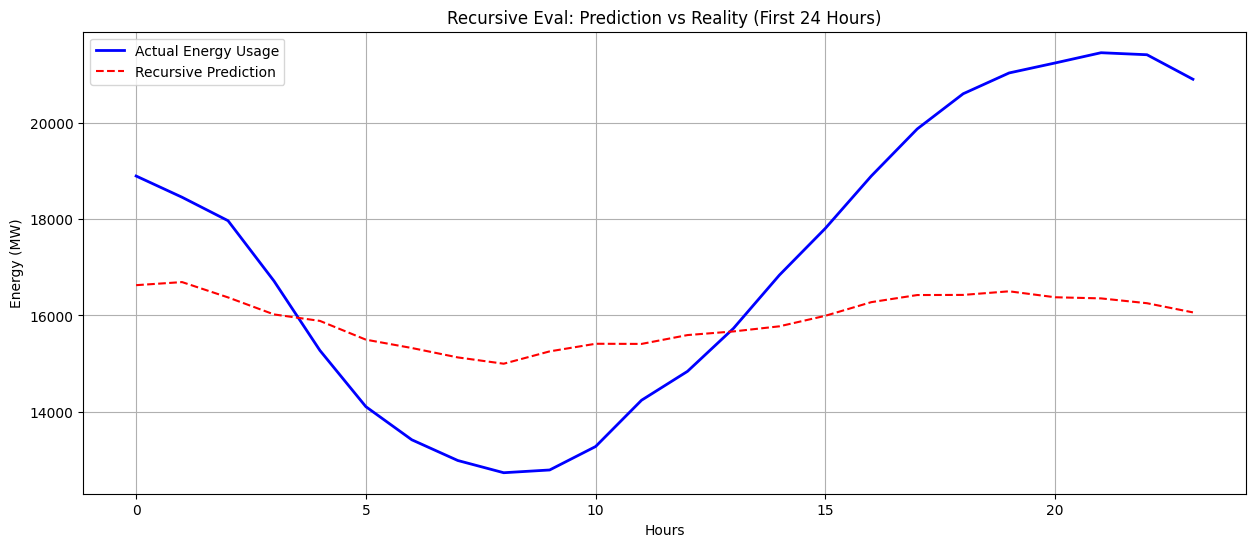

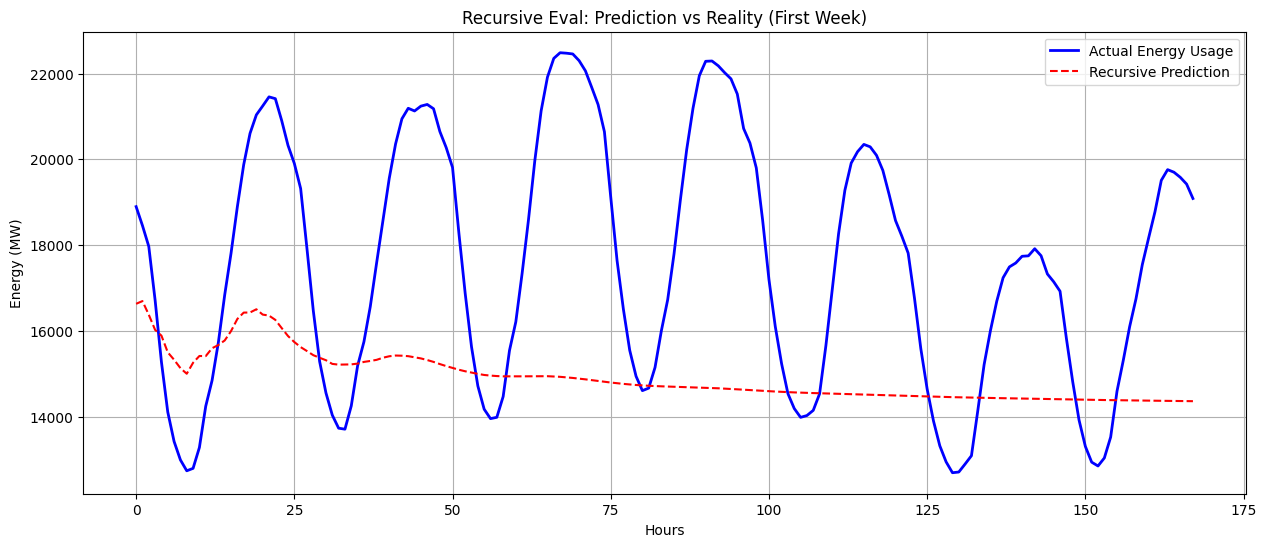

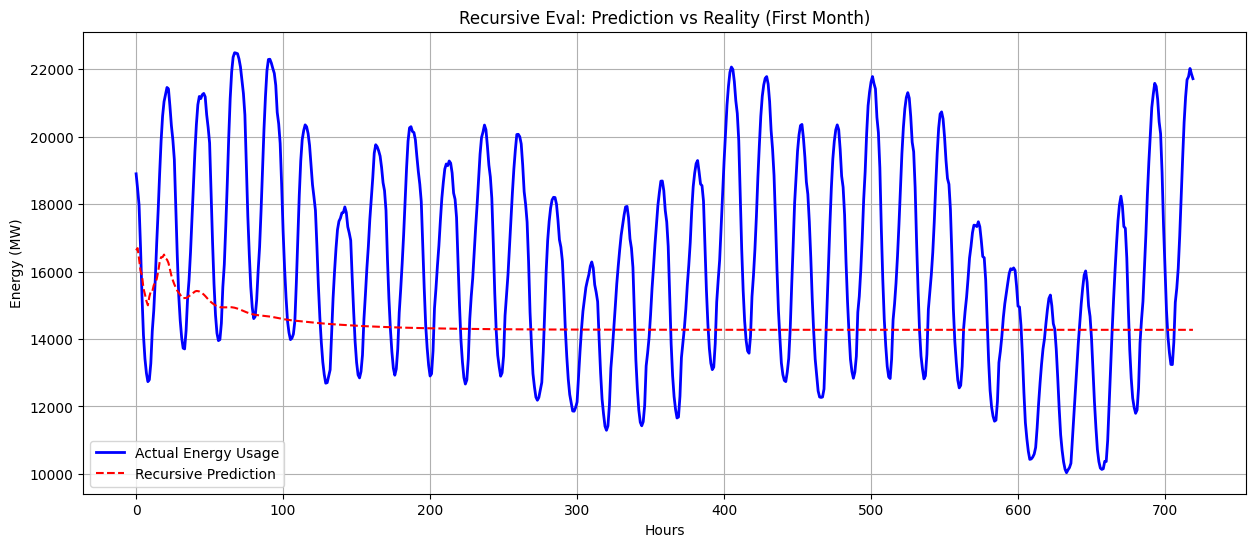

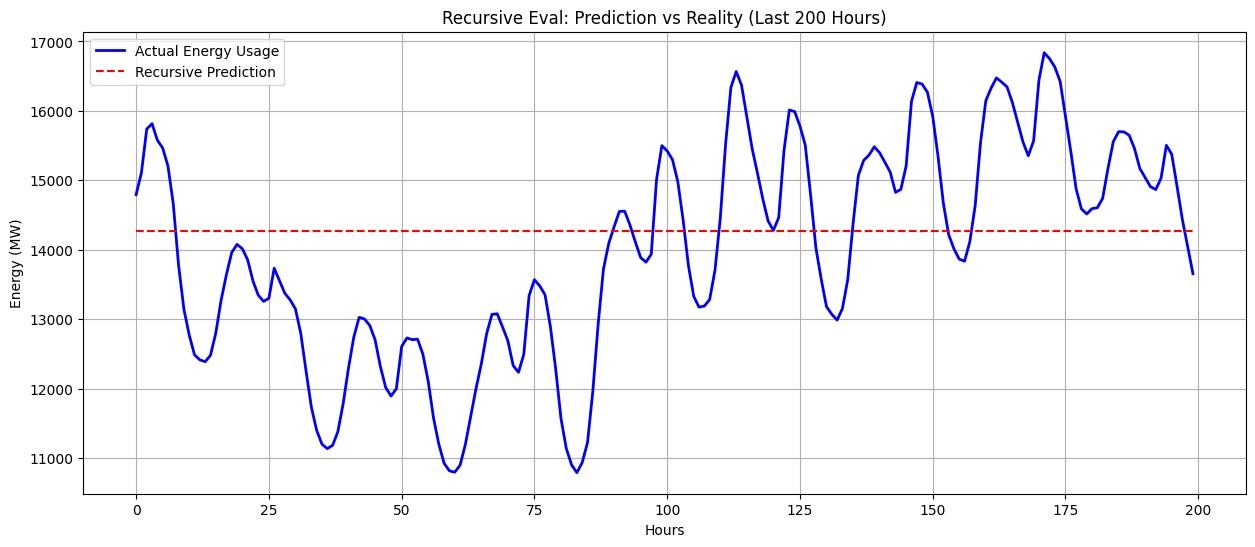

In [8]:
model.eval()

current_sequence = X_test_tensor[0].unsqueeze(0) 
predictions = []

with torch.no_grad():
    for i in range(len(y_test_tensor)):
        next_pred = model(current_sequence)
        predictions.append(next_pred.item())
        
        if len(current_sequence.shape) == 3 and len(next_pred.shape) == 2:
            next_pred_reshaped = next_pred.unsqueeze(1)
        else:
            next_pred_reshaped = next_pred
    
        current_sequence = torch.cat((current_sequence[:, 1:], next_pred_reshaped), dim=1)

test_predictions_mw = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
y_test_mw = scaler.inverse_transform(y_test_tensor.numpy())


# plot the first 24 hours
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:24], label='Actual Energy Usage', color='blue', linewidth=2)
plt.plot(test_predictions_mw[:24], label='Recursive Prediction', color='red', linestyle='--')
plt.title("Recursive Eval: Prediction vs Reality (First 24 Hours)")
plt.xlabel("Hours")
plt.ylabel("Energy (MW)")
plt.legend()
plt.grid(True)
plt.show()


# plot the first week 
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:168], label='Actual Energy Usage', color='blue', linewidth=2)
plt.plot(test_predictions_mw[:168], label='Recursive Prediction', color='red', linestyle='--')
plt.title("Recursive Eval: Prediction vs Reality (First Week)")
plt.xlabel("Hours")
plt.ylabel("Energy (MW)")
plt.legend()
plt.grid(True)
plt.show()

# plot the first month
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:720], label='Actual Energy Usage', color='blue', linewidth=2)
plt.plot(test_predictions_mw[:720], label='Recursive Prediction', color='red', linestyle='--')
plt.title("Recursive Eval: Prediction vs Reality (First Month)")
plt.xlabel("Hours")
plt.ylabel("Energy (MW)")
plt.legend()
plt.grid(True)
plt.show()

# plot the last 200 hours
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[-200:], label='Actual Energy Usage', color='blue', linewidth=2)
plt.plot(test_predictions_mw[-200:], label='Recursive Prediction', color='red', linestyle='--')
plt.title("Recursive Eval: Prediction vs Reality (Last 200 Hours)")
plt.xlabel("Hours")
plt.ylabel("Energy (MW)")
plt.legend()
plt.grid(True)
plt.show()

# RNN

we now try to work with a different model, the recurrent neural network

### RNN on 24 hours of data

Add two sinusoidal features for daily seasonality

In [ ]:
import random
import numpy as np
import torch
import os

def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

set_seed(42)

In [9]:
df_small = energy_data[(energy_data['date'] > '2015-01-01') & (energy_data['date'] < '2017-01-01')].copy()

df_small['hour_sin'] = np.sin(2 * np.pi * df_small['date'].dt.hour / 24.0)
df_small['hour_cos'] = np.cos(2 * np.pi * df_small['date'].dt.hour / 24.0)

train_size = int(len(df_small) * 0.8)
train_df = df_small.iloc[:train_size]
test_df = df_small.iloc[train_size:]

scaler = MinMaxScaler()
train_mw_scaled = scaler.fit_transform(train_df[['mw']].values)
test_mw_scaled = scaler.transform(test_df[['mw']].values)

train_multivariate = np.hstack((train_mw_scaled, train_df[['hour_sin', 'hour_cos']].values))
test_multivariate = np.hstack((test_mw_scaled, test_df[['hour_sin', 'hour_cos']].values))

# we modify one line from before to account for new features
def create_sequences(data, window_size):
    inputs = []
    targets = []
    for i in range(len(data) - window_size):
        x = data[i : i + window_size]
        y = data[i + window_size, 0]
        inputs.append(x)
        targets.append(y)
    return np.array(inputs), np.array(targets)

Architecture

In [ ]:
class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        # Pytorch syntax for a NN model
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        # batch_first=True means the input shape should be (batch_size, seq_length, input_size)
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        # layer for the final output
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # creates an initial hidden state (memory) made of zeros for the first iteration
        # to(x.device) ensures it's on the same device as the input (CPU or GPU)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        # out, _ because rnn returns two things and we don't need the second one
        out, _ = self.rnn(x, h0)
        # grab all batches, but then only the last time step
        # the RNN goes through every timestep from 1 to 24 but we only need the last one for the prediction
        # it then grabs all features
        out = self.fc(out[:, -1, :])
        return out

Training

In [11]:
WINDOW_SIZE = 24
X_train, y_train = create_sequences(train_multivariate, WINDOW_SIZE)
X_test, y_test = create_sequences(test_multivariate, WINDOW_SIZE)

# we need the .view(-1, 1) to make sure the target is the right shape for MSELoss (which expects [batch_size, output_size]) 
# instead of just  [batch_size]
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

model = VanillaRNN(input_size=3, hidden_size=128, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
print("Training Multivariate RNN...")
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    output = model(X_train_tensor)
    loss = criterion(output, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.5f}")



Training Multivariate RNN...
Epoch 0, Loss: 0.12928
Epoch 10, Loss: 0.01843
Epoch 20, Loss: 0.01546
Epoch 30, Loss: 0.01121
Epoch 40, Loss: 0.00637


Prediction

In [ ]:
model.eval()
sequential_predictions = []

# we copy (clone) the first test sequence of [24, 3], but we turn it into [1, 24, 3] so that Pytorch can process it
current_seq = X_test_tensor[0].unsqueeze(0).clone()

print("Generating sequential predictions...")
# torch.no_grad() makes it so Pytorch doesn't calculate gradients in this block (don't need to, it's prediction)
with torch.no_grad():
    for i in range(len(y_test_tensor)):
        pred_mw = model(current_seq)
        # .item() takes the single numerical value from the tensor, and we append it
        sequential_predictions.append(pred_mw.item())
        if i + 1 < len(X_test_tensor):
            # here we take the sinusoidal features from the test set so we don't have to recalculate them
            # takes the next 24 hours, takes the last hour and all 3 features. In addition, it turns it into [1, 1, 3] 
            # so that Pytorch can process it
            next_features = X_test_tensor[i + 1, -1, :].clone().unsqueeze(0).unsqueeze(0)
            # insert into it the new prediction value we just got
            next_features[0, 0, 0] = pred_mw.item()
            # now we concatenate the sequence with the new features
            # we end up creating a sequence that contains our predictions rather than the actual values
            current_seq = torch.cat((current_seq[:, 1:, :], next_features), dim=1)

# equivalent of .view(-1, 1) to make sure it's the right shape
sequential_predictions = np.array(sequential_predictions).reshape(-1, 1)
# inverse the MinMaxScaler transformation
test_predictions_mw = scaler.inverse_transform(sequential_predictions)
y_test_mw = scaler.inverse_transform(y_test_tensor.numpy())

Generating sequential predictions...


Plotting and evaluation measures

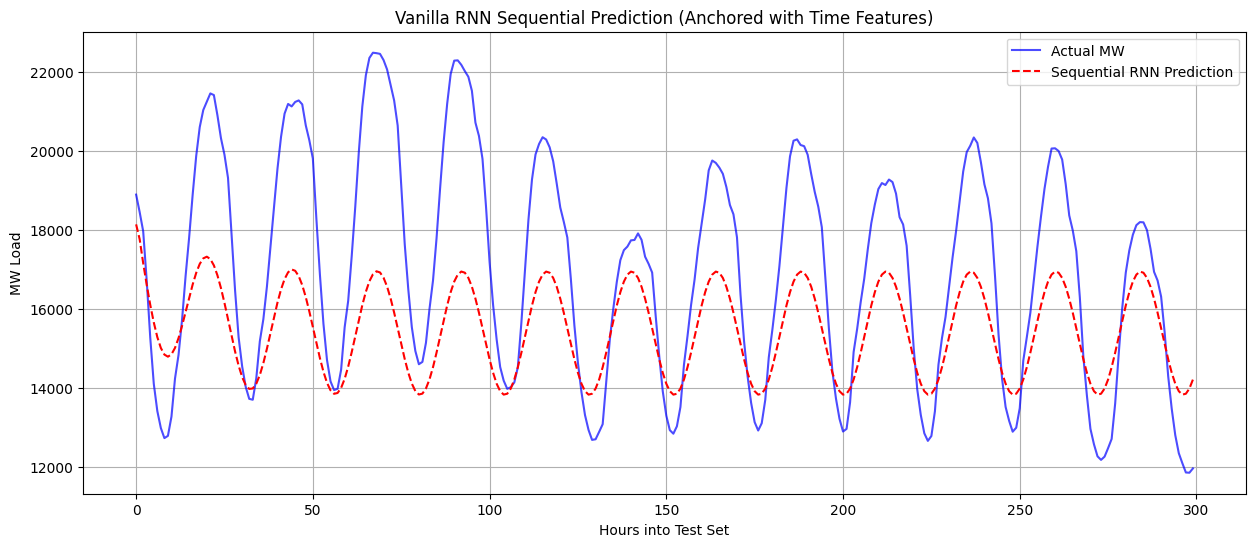

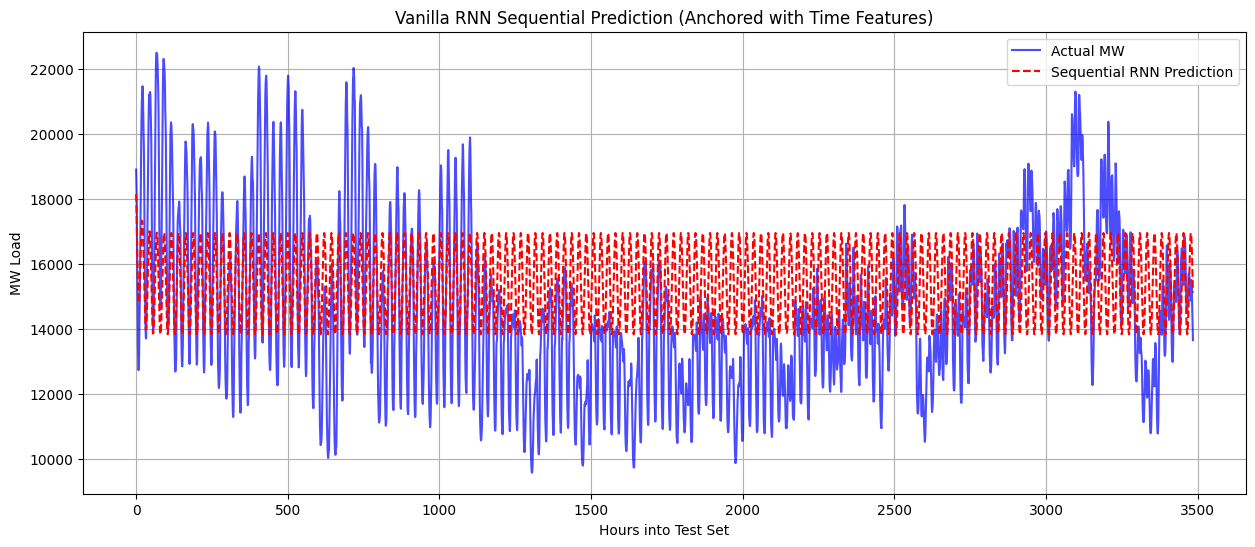

In [13]:
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:300], label='Actual MW', color='blue', alpha=0.7)
plt.plot(test_predictions_mw[:300], label='Sequential RNN Prediction', color='red', linestyle='--')
plt.title("Vanilla RNN Sequential Prediction (Anchored with Time Features)")
plt.xlabel("Hours into Test Set")
plt.ylabel("MW Load")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(15, 6))
plt.plot(y_test_mw, label='Actual MW', color='blue', alpha=0.7)
plt.plot(test_predictions_mw, label='Sequential RNN Prediction', color='red', linestyle='--')
plt.title("Vanilla RNN Sequential Prediction (Anchored with Time Features)")
plt.xlabel("Hours into Test Set")
plt.ylabel("MW Load")
plt.legend()
plt.grid(True)
plt.show()

We still need a concrete evaluation of the model, and for that we use MSE and MAPE
We want to beat some baseline "dumb" models to make sure we got something good

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mse = mean_squared_error(y_test_mw, test_predictions_mw)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_mw - test_predictions_mw) / y_test_mw)) * 100

print(f"--- Model Performance ---")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f}%")

# np.roll shifts the array by 1 (we take the previous hour's value)
y_naive = np.roll(y_test_mw, 1)
# The first element is now to be ignored
baseline_rmse = np.sqrt(mean_squared_error(y_test_mw[1:], y_naive[1:]))

print(f"\n--- Baseline Comparison ---")
print(f"Baseline (Persistence) RMSE: {baseline_rmse:.2f} MW")

if rmse < baseline_rmse:
    print(f"SUCCESS: Model beat the baseline by {baseline_rmse - rmse:.2f} MW")
else:
    print(f"FAILURE: Model is worse than just guessing 'same as last hour'.")

--- Model Performance ---
RMSE: 2320.58 MW
MAPE: 14.01%

--- Baseline Comparison ---
Baseline (Persistence) RMSE: 552.92 MW
FAILURE: Model is worse than just guessing 'same as last hour'.


# LSTM

we now try to use the LSTM model

We add:
- clock features with sine and cosine
- 24 hour chunk prediction
- lag features of some hours back, one week, one year and two years back

In [15]:
import random
import numpy as np
import torch
import os

def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)

set_seed(42)

In [16]:
df_small = energy_data[(energy_data['date'] < '2017-01-01') & 
                       (energy_data['date'] > '2007-01-01')].copy()

day_year = df_small['date'].dt.dayofyear
df_small['sin_year'] = np.sin(2 * np.pi * day_year / 365)
df_small['cos_year'] = np.cos(2 * np.pi * day_year / 365)
df_small['sin_hour'] = np.sin(2 * np.pi * df_small['date'].dt.hour / 24)
df_small['cos_hour'] = np.cos(2 * np.pi * df_small['date'].dt.hour / 24)
df_small['sin_day'] = np.sin(2 * np.pi * df_small['date'].dt.dayofweek / 7)
df_small['cos_day'] = np.cos(2 * np.pi * df_small['date'].dt.dayofweek / 7)

feature_cols = ['mw', 'sin_year', 'cos_year', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day']

train_size = int(len(df_small) * 0.8)
# .values returns a pure numpy array
train_raw = df_small[feature_cols].iloc[:train_size].values
test_raw = df_small[feature_cols].iloc[train_size:].values

scaler = MinMaxScaler()
# .reshape(-1, 1) turns 1D arrays into 2D arrays with one column (depends on what a function expects)
scaler.fit(train_raw[:, 0].reshape(-1, 1))

train_normalized = train_raw.copy()
test_normalized = test_raw.copy()

# .flatten() returns the 2D array back into a 1D array after scaling
train_normalized[:, 0] = scaler.transform(train_raw[:, 0].reshape(-1, 1)).flatten()
test_normalized[:, 0] = scaler.transform(test_raw[:, 0].reshape(-1, 1)).flatten()

In [17]:
def create_chunk_sequences(data):
    inputs = []
    targets = []
    max_lookback = 24 * 365 * 2
    prediction_window = 24 
    for i in range(max_lookback, len(data) - prediction_window):
        indices = []
        # these are our lag features
        for h in range(3, 0, -1): indices.append(i - h)
        indices.append(i - 24)
        indices.append(i - (24 * 7))
        indices.append(i - (24 * 365))
        indices.append(i - (24 * 365 * 2))
        
        inputs.append(data[indices])
        targets.append(data[i : i + prediction_window, 0]) 
        
    return np.array(inputs), np.array(targets)

X_train, y_train = create_chunk_sequences(train_normalized)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)

Architecture

In [18]:
class LSTMModel(nn.Module):
    # notice input_size=7 because we have 7 features (mw + 6 sinusoidal features)
    def __init__(self, input_size=7, hidden_size=128, output_size=24):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=6, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # like the RNN, we need to create initial hidden and cell states for the LSTM
        h0 = torch.zeros(6, x.size(0), 128).to(x.device)
        c0 = torch.zeros(6, x.size(0), 128).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        return self.fc(out[:, -1, :]) 

Training

In [19]:
model = LSTMModel()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

print("Training...")
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

for epoch in range(5): 
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X), batch_y)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1} Loss: {loss.item():.5f}")

Training...
Epoch 1 Loss: 0.00458
Epoch 2 Loss: 0.00259
Epoch 3 Loss: 0.00285
Epoch 4 Loss: 0.00395
Epoch 5 Loss: 0.00352


Prediction

In [20]:
model.eval()

# turns the training data into a list of rows
history = [row for row in train_normalized]
predictions = []
# this buffer is so we can extract the sinusoidal features more easily
lookback_buffer = train_normalized[-(24*365*2):]
# attaches the 2 years of lookback to the beginning of the test so we can extract the lag features
test_with_history = np.concatenate((lookback_buffer, test_normalized))
# calcs exactly how many times we need to run the loop
total_test_hours = len(test_normalized)
num_chunks = int(np.ceil(total_test_hours / 24))
# takes only the sinusoidal features
future_time_features = test_normalized[:, 1:] 

print(f"Predicting {num_chunks} chunks (Total ~{num_chunks*24} hours)...")

with torch.no_grad():
    for chunk_idx in range(num_chunks):
        t = len(history)
        indices = []
        # lag features        
        for h in range(3, 0, -1): indices.append(t - h)
        indices.append(t - 24)
        indices.append(t - (24 * 7))
        indices.append(t - (24 * 365))
        indices.append(t - (24 * 365 * 2))
        
        # takes the indexes from history (lag features) 
        seq_data = np.array([history[idx] for idx in indices])
        # turns them into a tensor and adds a dimension so it's [1, 7] instead of [7]
        current_input = torch.FloatTensor(seq_data).unsqueeze(0)
        # gets the 24 hour predicitons
        chunk_pred = model(current_input).numpy()[0]
        # add the predictions to the list of all predictions
        predictions.extend(chunk_pred)  
        # moevs to the next 24 hours   
        start_t = chunk_idx * 24
        end_t = start_t + 24
        current_chunk_times = future_time_features[start_t : end_t]

        # check that it doesn't go beyond if it doesn't have 24 hours left available
        if len(current_chunk_times) < 24:
            break
        
        # stack teh predictions with the sinusoidal features so we can add them to history
        new_rows = np.column_stack((chunk_pred, current_chunk_times))
        
        for row in new_rows:
            history.append(row)

Predicting 731 chunks (Total ~17544 hours)...


Plotting and Evaluation Metrics

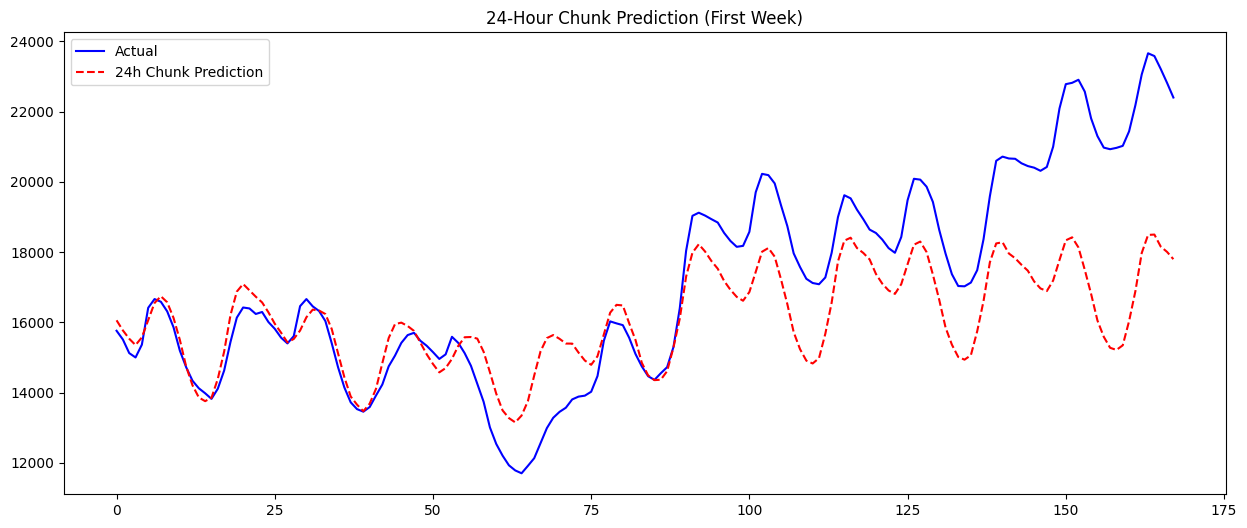

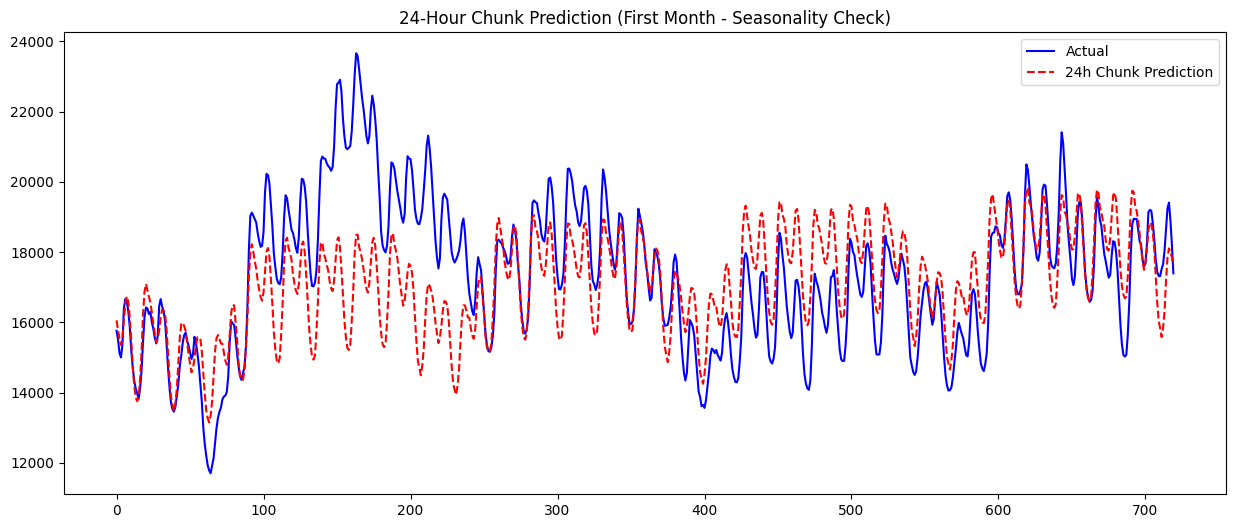

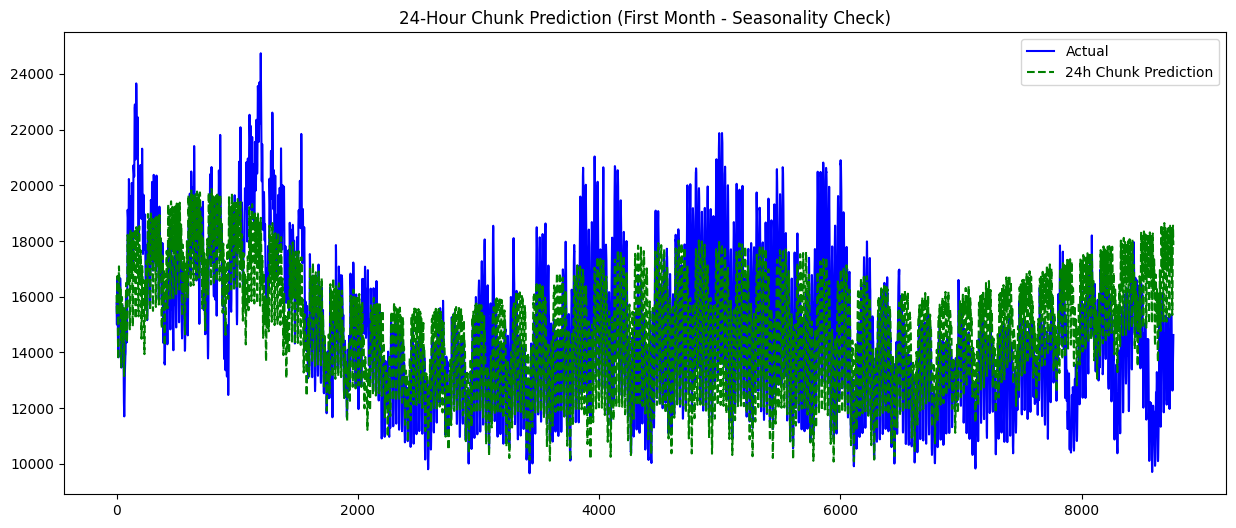

In [21]:
test_predictions_mw = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# we make sure to only print hours where we could look back 2 years (the lag features)
min_len = min(len(test_normalized), len(test_predictions_mw))
y_test_mw = scaler.inverse_transform(test_normalized[:min_len, 0].reshape(-1, 1))
test_predictions_mw = test_predictions_mw[:min_len]

# plot first week
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:168], label='Actual', color='blue')
plt.plot(test_predictions_mw[:168], label='24h Chunk Prediction', color='red', linestyle='--')
plt.title("24-Hour Chunk Prediction (First Week)")
plt.legend()
plt.show()

# plot first month
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:720], label='Actual', color='blue')
plt.plot(test_predictions_mw[:720], label='24h Chunk Prediction', color='red', linestyle='--')
plt.title("24-Hour Chunk Prediction (First Month - Seasonality Check)")
plt.legend()
plt.show()

# plot first year
plt.figure(figsize=(15, 6))
plt.plot(y_test_mw[:24*365], label='Actual', color='blue')
plt.plot(test_predictions_mw[:24*365], label='24h Chunk Prediction', color='green', linestyle='--')
plt.title("24-Hour Chunk Prediction (First Month - Seasonality Check)")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_squared_error
import numpy as np

test_predictions_mw = scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()

min_len = min(len(test_normalized), len(test_predictions_mw))
y_test_mw = scaler.inverse_transform(test_normalized[:min_len, 0].reshape(-1, 1)).flatten()
test_predictions_mw = test_predictions_mw[:min_len]

actuals = y_test_mw
preds = test_predictions_mw

horizons = {
    '24 Hours (1 Day)': 24,
    '168 Hours (1 Week)': 168,
    '720 Hours (1 Month)': 720,
    '8760 Hours (1 Year)': 8760
}
full_actuals = df_small['mw'].values

print("=== Horizon-Based Sequential Evaluation ===\n")

for name, h in horizons.items():
    # safety check
    if h > len(y_test_mw):
        print(f"[{name}] SKIP: Not enough data in the test set. (Test set size: {len(y_test_mw)}h, Needed: {h}h)\n")
        continue
        
    actuals_h = y_test_mw[:h]
    preds_h = test_predictions_mw[:h].flatten() 
    baseline_h = full_actuals[train_size - h : train_size]
    
    model_rmse = np.sqrt(mean_squared_error(actuals_h, preds_h))
    model_mape = np.mean(np.abs((actuals_h - preds_h) / actuals_h)) * 100
    
    baseline_rmse = np.sqrt(mean_squared_error(actuals_h, baseline_h))
    baseline_mape = np.mean(np.abs((actuals_h - baseline_h) / actuals_h)) * 100
    
    print(f"--- {name} ---")
    print(f"Model RMSE:    {model_rmse:.2f} MW  |  MAPE: {model_mape:.2f}%")
    print(f"Baseline RMSE: {baseline_rmse:.2f} MW  |  MAPE: {baseline_mape:.2f}%")
    
    if model_rmse < baseline_rmse:
        diff = baseline_rmse - model_rmse
        print(f"SUCCESS: Model BEAT baseline by {diff:.2f} MW")
    else:
        diff = model_rmse - baseline_rmse
        print(f"FAILURE: Model LOST to baseline by {diff:.2f} MW")
    print("-" * 45)

=== Horizon-Based Sequential Evaluation ===

--- 24 Hours (1 Day) ---
Model RMSE:    384.93 MW  |  MAPE: 2.12%
Baseline RMSE: 1305.36 MW  |  MAPE: 7.78%
SUCCESS: Model BEAT baseline by 920.43 MW
---------------------------------------------
--- 168 Hours (1 Week) ---
Model RMSE:    2174.29 MW  |  MAPE: 8.37%
Baseline RMSE: 2669.94 MW  |  MAPE: 11.91%
SUCCESS: Model BEAT baseline by 495.65 MW
---------------------------------------------
--- 720 Hours (1 Month) ---
Model RMSE:    1706.83 MW  |  MAPE: 7.19%
Baseline RMSE: 2828.75 MW  |  MAPE: 13.32%
SUCCESS: Model BEAT baseline by 1121.92 MW
---------------------------------------------
--- 8760 Hours (1 Year) ---
Model RMSE:    1700.96 MW  |  MAPE: 8.83%
Baseline RMSE: 2136.61 MW  |  MAPE: 10.73%
SUCCESS: Model BEAT baseline by 435.65 MW
---------------------------------------------


### Expanding Window


FOLD 1: Train -> 2007-2009 | Test -> 2010
Training on 8754 samples...
  Epoch 1 Loss: 0.02556
  Epoch 2 Loss: 0.01314
  Epoch 3 Loss: 0.01222
  Epoch 4 Loss: 0.00656
  Epoch 5 Loss: 0.00469
Predicting 2010 in 365 chunks...
--> Fold 1 (2010) Results: RMSE: 1791.67 MW | MAPE: 0.0811

FOLD 2: Train -> 2007-2010 | Test -> 2011
Training on 17511 samples...
  Epoch 1 Loss: 0.02144
  Epoch 2 Loss: 0.00903
  Epoch 3 Loss: 0.00472
  Epoch 4 Loss: 0.00375
  Epoch 5 Loss: 0.00343
Predicting 2011 in 365 chunks...
--> Fold 2 (2011) Results: RMSE: 2031.75 MW | MAPE: 0.0978

FOLD 3: Train -> 2007-2011 | Test -> 2012
Training on 26269 samples...
  Epoch 1 Loss: 0.01866
  Epoch 2 Loss: 0.00583
  Epoch 3 Loss: 0.00364
  Epoch 4 Loss: 0.00332
  Epoch 5 Loss: 0.00322
Predicting 2012 in 366 chunks...
--> Fold 3 (2012) Results: RMSE: 1330.42 MW | MAPE: 0.0635

FOLD 4: Train -> 2007-2012 | Test -> 2013
Training on 35050 samples...
  Epoch 1 Loss: 0.01600
  Epoch 2 Loss: 0.00436
  Epoch 3 Loss: 0.00354
  Epo

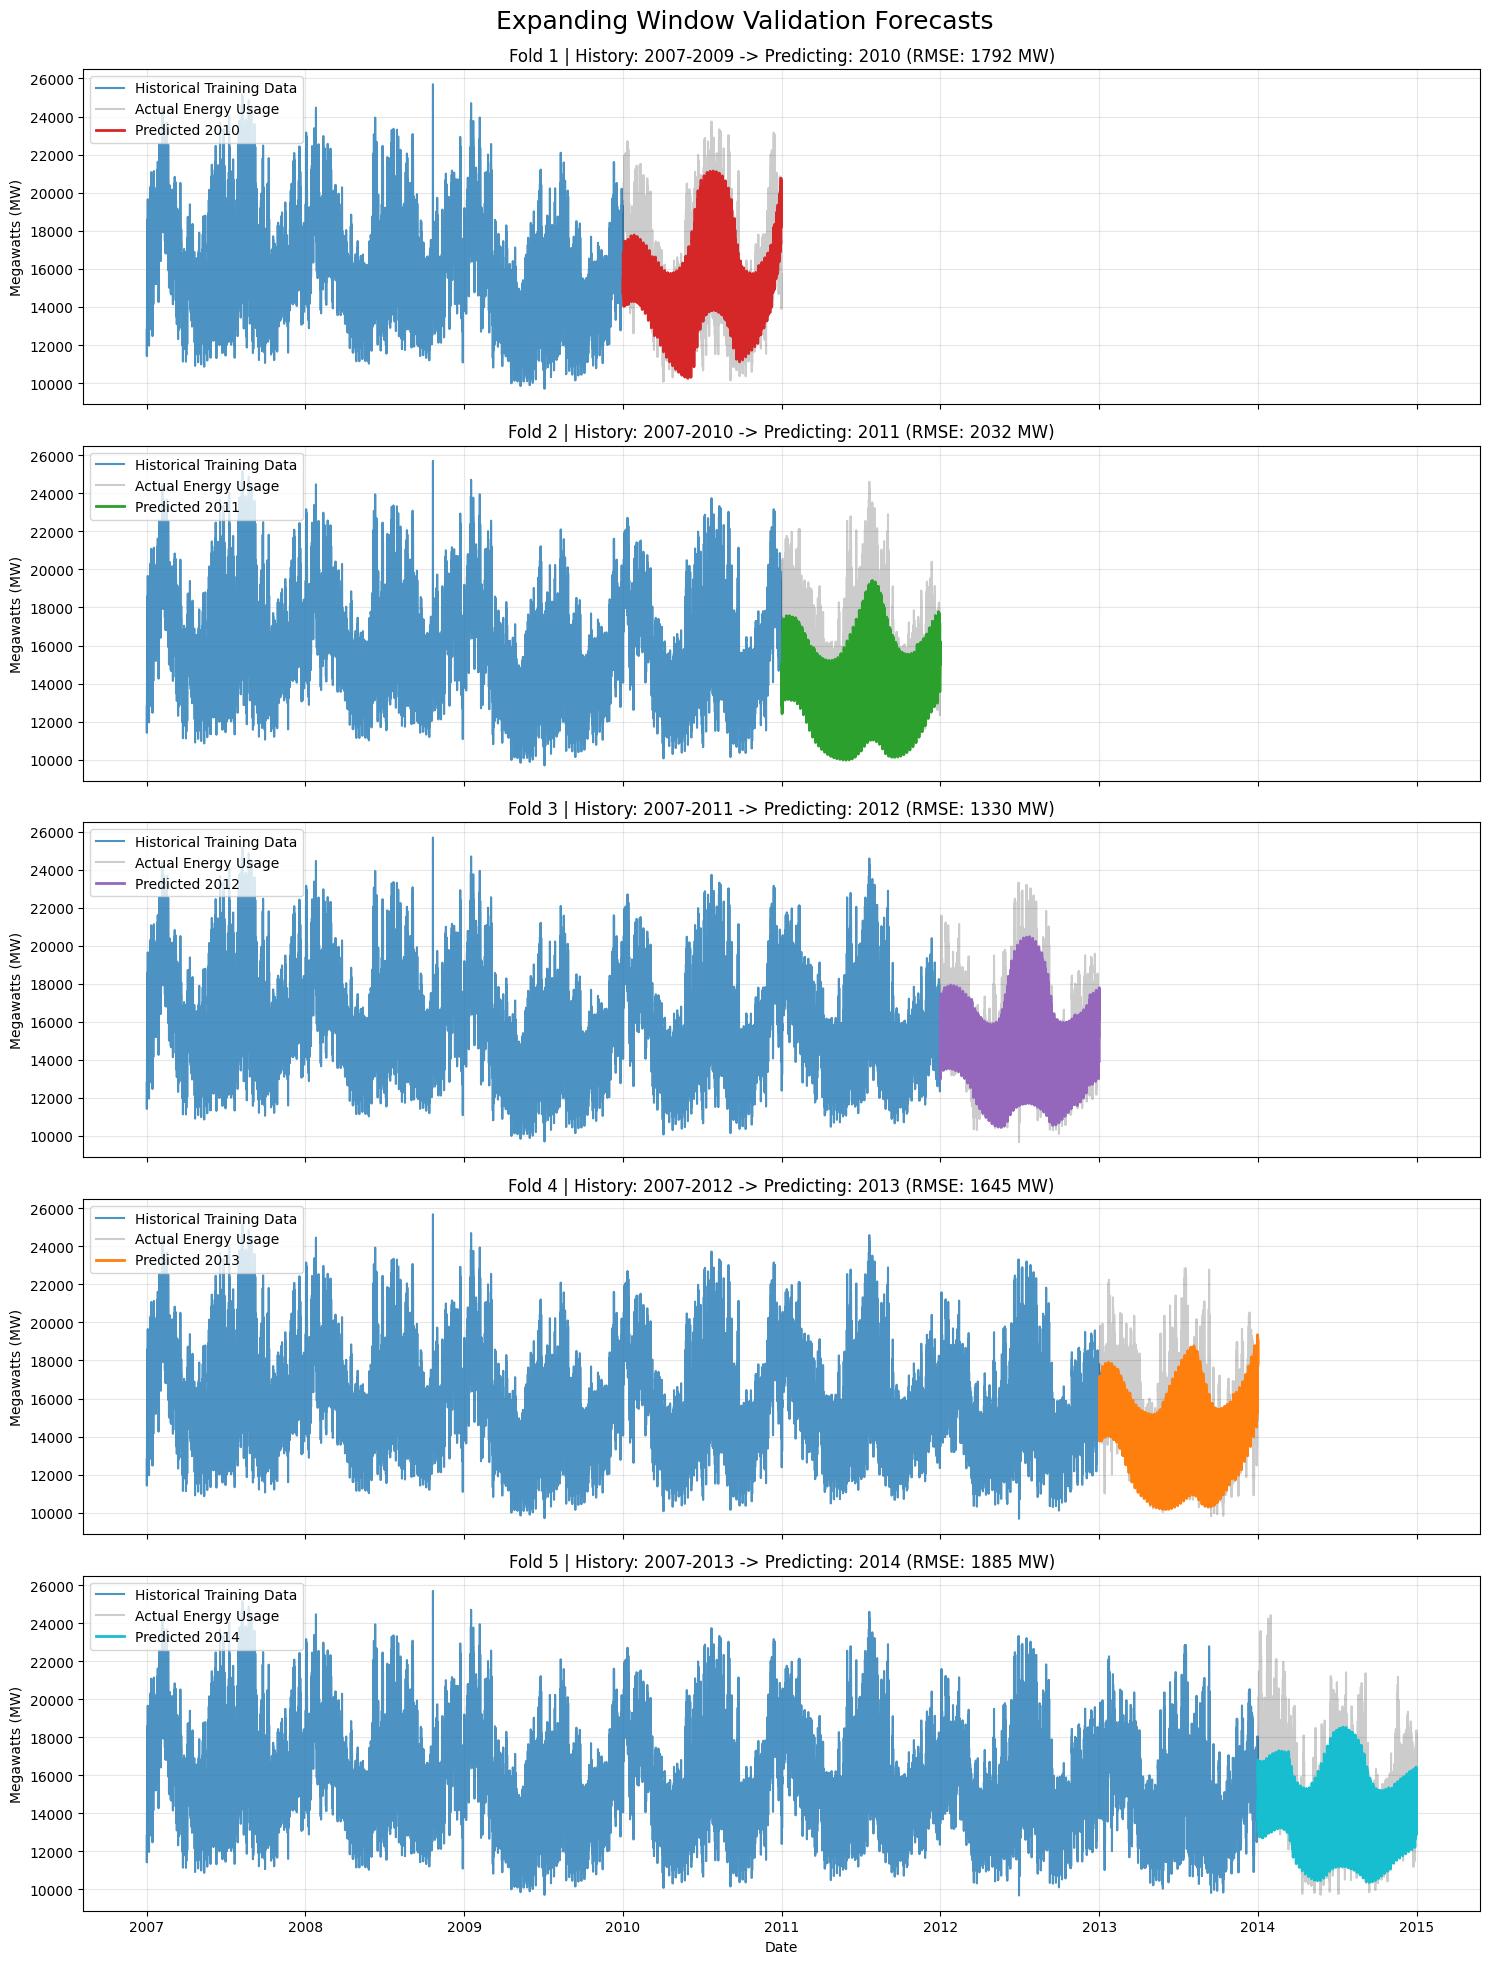

In [23]:
def set_seed(seed_value=42):
    random.seed(seed_value)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

energy_data['year'] = energy_data['date'].dt.year

df_small = energy_data[(energy_data['year'] <= 2017) & (energy_data['year'] >= 2007)].copy()

day_year = df_small['date'].dt.dayofyear
df_small['sin_year'] = np.sin(2 * np.pi * day_year / 365)
df_small['cos_year'] = np.cos(2 * np.pi * day_year / 365)
df_small['sin_hour'] = np.sin(2 * np.pi * df_small['date'].dt.hour / 24)
df_small['cos_hour'] = np.cos(2 * np.pi * df_small['date'].dt.hour / 24)
df_small['sin_day'] = np.sin(2 * np.pi * df_small['date'].dt.dayofweek / 7)
df_small['cos_day'] = np.cos(2 * np.pi * df_small['date'].dt.dayofweek / 7)

feature_cols = ['mw', 'sin_year', 'cos_year', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day']

start_year = 2007
initial_train_years = 3
num_folds = 5
fold_metrics = []

for fold in range(num_folds):
    train_end_year = start_year + initial_train_years + fold
    test_year = train_end_year 
    
    print(f"\n{'='*50}")
    print(f"FOLD {fold + 1}: Train -> {start_year}-{train_end_year-1} | Test -> {test_year}")
    print(f"{'='*50}")
    
    df_train = df_small[df_small['year'] < test_year].copy()
    df_test = df_small[df_small['year'] == test_year].copy()
    
    train_raw = df_train[feature_cols].values
    test_raw = df_test[feature_cols].values

    scaler = MinMaxScaler()
    scaler.fit(train_raw[:, 0].reshape(-1, 1))
    
    train_normalized = train_raw.copy()
    test_normalized = test_raw.copy()
    train_normalized[:, 0] = scaler.transform(train_raw[:, 0].reshape(-1, 1)).flatten()
    test_normalized[:, 0] = scaler.transform(test_raw[:, 0].reshape(-1, 1)).flatten()
    
    X_train, y_train = create_chunk_sequences(train_normalized)

    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train) 
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    
    model = LSTMModel()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    print(f"Training on {len(X_train)} samples...")
    for epoch in range(5): 
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        print(f"  Epoch {epoch+1} Loss: {epoch_loss/len(train_loader):.5f}")

    model.eval()
    history = [row for row in train_normalized]
    predictions = []
    
    lookback_buffer = train_normalized[-(24*365*2):]
    test_with_history = np.concatenate((lookback_buffer, test_normalized))
    
    total_test_hours = len(test_normalized)
    num_chunks = int(np.ceil(total_test_hours / 24))
    future_time_features = test_normalized[:, 1:] 
    
    print(f"Predicting {test_year} in {num_chunks} chunks...")
    with torch.no_grad():
        for chunk_idx in range(num_chunks):
            t = len(history)
            indices = []
            
            for h in range(3, 0, -1): indices.append(t - h)
            indices.append(t - 24)
            indices.append(t - (24 * 7))
            indices.append(t - (24 * 365))
            indices.append(t - (24 * 365 * 2))
            
            seq_data = np.array([history[idx] for idx in indices])
            current_input = torch.FloatTensor(seq_data).unsqueeze(0)
            chunk_pred = model(current_input).numpy()[0]
            
            predictions.extend(chunk_pred)
            
            start_t = chunk_idx * 24
            end_t = start_t + 24
            current_chunk_times = future_time_features[start_t : end_t]
            
            if len(current_chunk_times) < 24:
                predictions = predictions[:-(24 - len(current_chunk_times))]
                break
                
            new_rows = np.column_stack((chunk_pred, current_chunk_times))
            for row in new_rows:
                history.append(row)
                
    test_predictions_mw = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))
    
    min_len = min(len(test_normalized), len(test_predictions_mw))
    y_test_mw = scaler.inverse_transform(test_normalized[:min_len, 0].reshape(-1, 1))
    test_predictions_mw = test_predictions_mw[:min_len]
    
    rmse = np.sqrt(mean_squared_error(y_test_mw, test_predictions_mw))
    mape = mean_absolute_percentage_error(y_test_mw, test_predictions_mw)
    
    print(f"--> Fold {fold+1} ({test_year}) Results: RMSE: {rmse:.2f} MW | MAPE: {mape:.4f}")
    fold_metrics.append({
        'fold': fold + 1, 
        'year': test_year, 
        'rmse': rmse, 
        'mape': mape,
        'train_dates': df_train['date'].values,
        'train_actuals': df_train['mw'].values,
        'test_dates': df_test['date'].values[:min_len],
        'test_actuals': y_test_mw.flatten(),
        'test_preds': test_predictions_mw.flatten()
    })

print(f"\n{'='*50}")
print("FINAL EXPANDING WINDOW RESULTS")
print(f"{'='*50}")
avg_rmse = np.mean([m['rmse'] for m in fold_metrics])
avg_mape = np.mean([m['mape'] for m in fold_metrics])

for m in fold_metrics:
    print(f"Year {m['year']} - RMSE: {m['rmse']:.2f} | MAPE: {m['mape']:.4f}")
print("-" * 50)
print(f"AVERAGE RMSE: {avg_rmse:.2f} MW")
print(f"AVERAGE MAPE: {avg_mape:.4f}")


# nice plots we like
fig, axes = plt.subplots(num_folds, 1, figsize=(15, 20), sharex=True)
fig.suptitle("Expanding Window Validation Forecasts", fontsize=18, y=0.98)

forecast_colors = ['tab:red', 'tab:green', 'tab:purple', 'tab:orange', 'tab:cyan']

for i, m in enumerate(fold_metrics):
    ax = axes[i]
    
    # plot history
    ax.plot(m['train_dates'], m['train_actuals'], 
            label='Historical Training Data', color='#1f77b4', alpha=0.8)
    
    # plot actual future
    ax.plot(m['test_dates'], m['test_actuals'], 
            label='Actual Energy Usage', color='black', alpha=0.2, linestyle='-')
    
    # plot predictions
    ax.plot(m['test_dates'], m['test_preds'], 
            label=f"Predicted {m['year']}", color=forecast_colors[i % len(forecast_colors)], linewidth=2)
    
    ax.set_title(f"Fold {m['fold']} | History: 2007-{m['year']-1} -> Predicting: {m['year']} (RMSE: {m['rmse']:.0f} MW)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("Megawatts (MW)")

plt.xlabel("Date")
plt.tight_layout()
plt.subplots_adjust(top=0.95) 
plt.show()

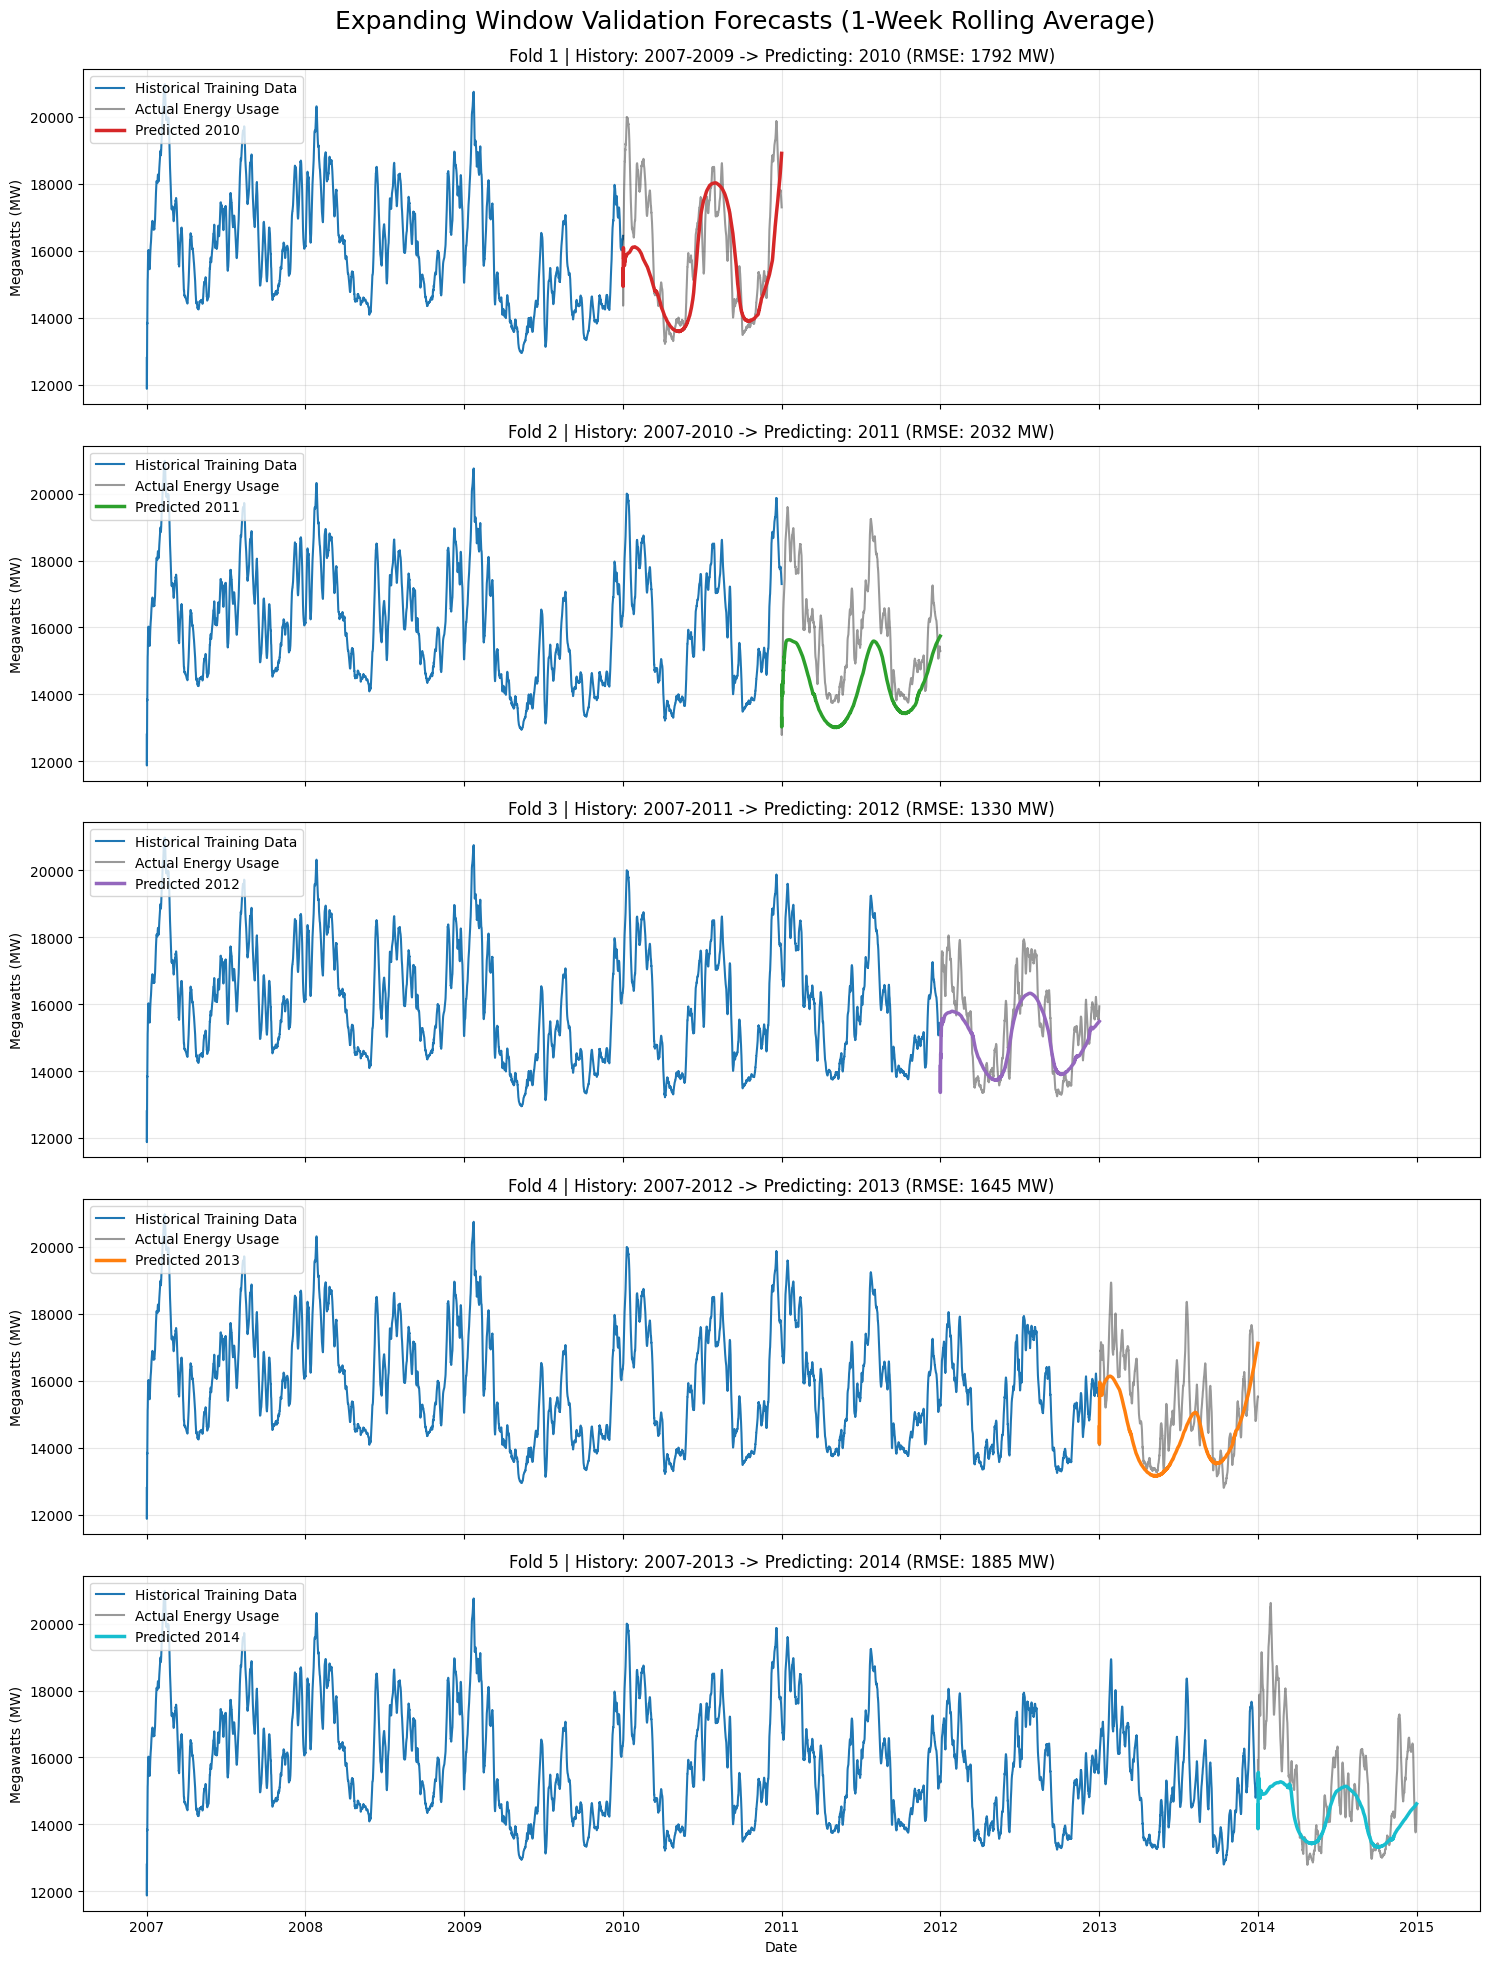

In [24]:
fig, axes = plt.subplots(num_folds, 1, figsize=(15, 20), sharex=True)
fig.suptitle("Expanding Window Validation Forecasts (1-Week Rolling Average)", fontsize=18, y=0.98)
forecast_colors = ['tab:red', 'tab:green', 'tab:purple', 'tab:orange', 'tab:cyan']
window_size = 168 

for i, m in enumerate(fold_metrics):
    ax = axes[i]
    
    def apply_smoothing(data_array):
        return pd.Series(data_array).rolling(window=window_size, min_periods=1).mean().values
    
    smooth_train = apply_smoothing(m['train_actuals'])
    smooth_actuals = apply_smoothing(m['test_actuals'])
    smooth_preds = apply_smoothing(m['test_preds'])
    
    # plot history
    ax.plot(m['train_dates'], smooth_train, 
            label='Historical Training Data', color='#1f77b4', linewidth=1.5)
    
    # plot actuals
    ax.plot(m['test_dates'], smooth_actuals, 
            label='Actual Energy Usage', color='black', alpha=0.4, linestyle='-', linewidth=1.5)
    
    # plot predictions
    ax.plot(m['test_dates'], smooth_preds, 
            label=f"Predicted {m['year']}", color=forecast_colors[i % len(forecast_colors)], linewidth=2.5)
    
    ax.set_title(f"Fold {m['fold']} | History: 2007-{m['year']-1} -> Predicting: {m['year']} (RMSE: {m['rmse']:.0f} MW)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel("Megawatts (MW)")

plt.xlabel("Date")
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()